In [1]:
# ============================================================
# S CrA streamer fitting script（整理版）
#
# 區塊結構：
#   1) 參數宣告 / Imports / 開關
#   2) 定義函數 (helpers & MCMC moves)
#   3) 資料前處理：mask streamer、平移至中心、抽質心
#   4) Grid fitting：用 11 點 error_function 找初始解
#   5) 用 grid 結果自動決定 MCMC 先驗範圍
#   6) MCMC_grid   ：11 點 + fast likelihood（選配）
#   7) MCMC_3D     ：(Theta, Phi, Incl) wide prior（選配）
#   8) MCMC_distance：distance_cube + log_posterior（cube，選配）
#   9) 多峰 refinement（選配）
# ============================================================

# ---------- 1. 參數宣告 / Imports / 開關 ----------
# 標準函式庫
import sys
import os
import warnings

# 額外工具
import cv2

# 第三方函式庫 (科學計算/優化)
import emcee
import numpy as np
import scipy.constants as spc

from scipy.interpolate import interp1d

# 天文學/數據處理函式庫
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from spectral_cube import SpectralCube

# 繪圖函式庫
import matplotlib as mpl
import matplotlib.pyplot as plt
import corner
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
from matplotlib.ticker import FuncFormatter, FormatStrFormatter

# For grid search progress
from tqdm.auto import tqdm
from itertools import product

# 後驗分析 / 工具
from scipy.signal import find_peaks

# 專案本地模組
import PSSpy as pss

# --- 基本天文參數（S CrA） ---
Local_Standard_Velocity = 5.86  # km/s (Gupta 2024)
pa_deg = 310.0
pa_rad = np.deg2rad(pa_deg)
distance_pc = 160.0
M_SUN_KG = 1.98847e30
radius_ref_au = 280
M_star = 2

scale = "log"
log_power = 1.5

radius_in_au, radius_out_au = 2.8e2, 5e3
# 資料與輸出
cube_fname = "S_CrA_13CO_spw25_tav_jupyter_shifted.fits"
PLOT_DIR = "S-CrA_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# --- 分析開關 ---
RUN_GRID = True             # 5D grid search 找初始解（建議開）
RUN_MCMC_GRID = False       # 11 個質心點 fast likelihood
RUN_MCMC_3D = False         # 三參數 (Theta, Phi, Incl) 測試
RUN_MCMC_DISTANCE = False    # 使用 distance_cube 的 5D MCMC
RUN_MCMC_GRID_REFINE = False  # 自動對多峰 posterior 做局部 MCMC refinement

# ============================================================
# 2. 定義函數 (helpers & moves)
# ============================================================

def get_mcmc_moves(mode="explore"):
    """
    回傳 emcee moves。
    mode:
      - "explore": 偏探索 (DE + Snooker)
      - "refine" : 偏收斂 (StretchMove)
      - 其他     : 折衷

    Moves 說明：
      - StretchMove：affine-invariant，收斂穩定，適合 refine
      - DEMove：差分進化（Differential Evolution），跳躍性大，探索性強
      - DESnookerMove：特殊反射式 move，有助於跳出局部極值
    """
    if mode == "explore":
        # 以探索為主：DEMove 為主，Snooker 輔助，StretchMove 較少
        return [
            (emcee.moves.StretchMove(a=2.5), 0.3),   # affine-invariant，收斂穩定，適合 refine
            (emcee.moves.DEMove(),           0.6),   # 差分進化，跳躍性大，探索性強
            (emcee.moves.DESnookerMove(),    0.1),   # 反射式 move，有助於跳出局部極值
        ]
    elif mode == "refine":
        # 以收斂為主：StretchMove 為主，DEMove 輔助
        return [
            (emcee.moves.StretchMove(a=2.5), 0.8),   # affine-invariant，收斂穩定，適合 refine
            (emcee.moves.DEMove(),           0.1),   # 差分進化，跳躍性大，探索性強
            (emcee.moves.DESnookerMove(),    0.1),   # 反射式 move，有助於跳出局部極值
        ]
    else:
        # 折衷模式：各 move 均衡
        return [
            (emcee.moves.StretchMove(a=2.5), 0.4),   # affine-invariant，收斂穩定，適合 refine
            (emcee.moves.DEMove(),           0.4),   # 差分進化，跳躍性大，探索性強
            (emcee.moves.DESnookerMove(),    0.2),   # 反射式 move，有助於跳出局部極值
        ]

# --- S CrA streamer masking/centroid helper ---
def build_streamer_masked_cube_scra(subcube, header, rms_channel, im_center):
    """
    S CrA 專用：
    1) 先用大圓遮掉中心，搭配 grow_region 找出 streamer 區域
    2) 再加上兩個額外圓形遮罩清掉多餘 emission
    3) 對整個 streamer cube 做平移，使 streamer 盡量置中
    回傳：
      shifted_cube_data : 平移後的 streamer 資料立方體 (numpy array, NaN=無效)
      shifted_mom0      : 對應 moment0
      shifted_mom1      : 對應 moment1
    """
    ny, nx = subcube.shape[1], subcube.shape[2]

    # 以兩個亮區中點當作初始中心 (這裡沿用你之前使用的座標)
    center1 = (388, 393)  # (y, x)
    center2 = (369, 382)  # (y, x)
    new_center = (int((center1[0] + center2[0]) / 2),
                  int((center1[1] + center2[1]) / 2))
    
    # 1) 大圓遮中心 + grow_region 長出 streamer
    radius_center = 35
    mask2d = pss.circular_mask((ny, nx), new_center, radius_center)
    mask3d = np.repeat(mask2d[np.newaxis, :, :], subcube.shape[0], axis=0)
    masked_center_cube = subcube.with_mask(mask3d)
    maskcent_cube_data = masked_center_cube.filled_data[:].value

    # grow_region 找 streamer
    init_points = [
        (35, new_center[0], new_center[1]),
        (35, 355, 371),
        (35, 355, 340),
        (35, 369, 309),
        (35, 389, 279),
        (35, 463, 257),
    ]
    stream_mask = pss.grow_region(
        maskcent_cube_data,
        init_points,
        rms_channel,
        sigma_thresh=3.5,
        max_iter=1000,
    )

    masked_cube = masked_center_cube.with_mask(stream_mask)
    # 2) 額外兩個圓形遮罩，清掉雜訊/多餘結構
    ny, nx = masked_cube.shape[1], masked_cube.shape[2]

    # mask 1
    radius1 = 11
    pos1 = [320, 412]  # (y, x)
    m2d_1 = pss.circular_mask((ny, nx), pos1, radius1)
    m3d_1 = np.repeat(m2d_1[np.newaxis, :, :], masked_cube.shape[0], axis=0)
    masked_cube = masked_cube.with_mask(m3d_1)
    
    # mask 2
    radius2 = 30
    pos2 = [335, 438]  # (y, x)
    m2d_2 = pss.circular_mask((ny, nx), pos2, radius2)
    m3d_2 = np.repeat(m2d_2[np.newaxis, :, :], masked_cube.shape[0], axis=0)
    masked_cube = masked_cube.with_mask(m3d_2)

    # 3) 對 streamer cube 做平移，讓 new_center 對齊 im_center
    new_cube_data = masked_cube.with_fill_value(np.nan).filled_data[:].value

    nv = new_cube_data.shape[0]
    ty = im_center[0] - new_center[0]
    tx = im_center[1] - new_center[1]
    M = np.float32([[1, 0, tx], [0, 1, ty]])

    shifted_cube_data = np.full_like(new_cube_data, np.nan)
    for v_slice in range(nv):
        shifted_slice = cv2.warpAffine(
            new_cube_data[v_slice],
            M,
            (nx, ny),
            borderValue=np.nan,
        )
        shifted_cube_data[v_slice] = shifted_slice

    # 對平移後的 cube 算 moment
    shifted_mom0 = np.nanmean(shifted_cube_data, axis=0)
    # 使用帶權平均時要避開 NaN
    with np.errstate(invalid="ignore"):
        # 速度軸的實際 km/s 由外部計算，這裡先由 subcube 提供
        spec = subcube.spectral_axis.to(u.km/u.s).value
        spec2d = np.repeat(spec[:, None, None], ny, axis=1)
        spec2d = np.repeat(spec2d, nx, axis=2)
        shifted_mom1 = np.nansum(shifted_cube_data * spec2d, axis=0) / np.nansum(
            shifted_cube_data, axis=0
        )

    return shifted_cube_data, shifted_mom0, shifted_mom1


def extract_streamer_centroids(new_cube_data, header, pa_rad, dx_au,
                               v_lastch_vel, v_lastch_num):
    """
    從 masked cube 抽出 11 個 streamer 質心點。
    回傳: x_AU, z_AU, v_LSR_km
    """
    cube_shape = new_cube_data.shape
    im_center = (int(header["CRPIX2"]), int(header["CRPIX1"]))

    v, z, x = np.indices(cube_shape)
    x_rel = x - im_center[1]
    z_rel = z - im_center[0]
    r, theta = pss.spherical_coords(x_rel, z_rel)

    # 使用實際 streamer 標記點決定流線方向
    find_streamcom = np.array([
        [396, 396],
        [371, 355],
        [340, 355],
        [309, 369],
        [279, 389],
        [257, 463],
    ]) - (im_center[0], im_center[1])  # (y, x) 轉為相對中心座標

    find_x = find_streamcom[:, 1]   # x 偏移
    find_y = find_streamcom[:, 0]   # y 偏移
    find_r, find_theta = pss.spherical_coords(find_x, find_y)
    find_streaml = interp1d(find_r, find_theta, fill_value="extrapolate")

    N = 11
    pars = np.linspace(40, 160, N + 1)

    x_means = np.zeros(N)
    z_means = np.zeros(N)
    v_means = np.zeros(N)
    xzstd   = np.zeros(N)

    # step 1: 幾何中心
    for i in range(N):
        r_mid = 0.5 * (pars[i] + pars[i+1])
        theta0 = find_streaml(r_mid)

        weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r
        weight_theta[r == 0] = 0
        # weight_theta[weight_theta < 0.99] = 0

        d = (
            (r > pars[i]) & (r <= pars[i+1]) &
            np.isfinite(new_cube_data) &
            (new_cube_data > 0)
        )
        if np.sum(d) > 0:
            w = new_cube_data[d] * weight_theta[d]
            x_means[i] = np.average(x_rel[d], weights=w)
            z_means[i] = np.average(z_rel[d], weights=w)
            xzstd[i]   = np.sqrt(np.average(
                (x_rel[d] - x_means[i])**2 +
                (z_rel[d] - z_means[i])**2, weights=w))
        else:
            x_means[i] = np.nan
            z_means[i] = np.nan
            xzstd[i]   = np.nan

    # step 2: r-theta, r-std 插值
    valid = np.isfinite(x_means)
    if np.sum(valid) < 2:
        raise RuntimeError("質心點太少，無法建立內插。")

    r_m, theta_m = pss.spherical_coords(x_means[valid], z_means[valid])
    theta_r = interp1d(r_m, theta_m,
                       fill_value=(theta_m[0], theta_m[-1]),
                       bounds_error=False)
    std_r = interp1d(r_m, xzstd[valid],
                     fill_value=(xzstd[0], xzstd[-1]),
                     bounds_error=False)

    # step 3: 高斯權重加上 v
    for i in range(N):
        r_mid = 0.5 * (pars[i] + pars[i+1])
        if not np.isfinite(x_means[i]):
            x_means[i] = np.nan
            z_means[i] = np.nan
            v_means[i] = np.nan
            continue

        theta_ref = theta_r(r_mid)
        std_ref = std_r(r_mid) / r_mid

        delta_theta = np.pi - np.abs(np.pi - np.abs(theta - theta_ref))
        weights = new_cube_data * pss.gaussian(delta_theta, 0, std_ref)

        d = (r > pars[i]) & (r <= pars[i+1]) & (new_cube_data > 0) & np.isfinite(new_cube_data)
        if np.sum(d) > 0:
            x_means[i] = np.average(x_rel[d], weights=weights[d])
            z_means[i] = np.average(z_rel[d], weights=weights[d])
            v_means[i] = np.average(v[d],    weights=weights[d])
        else:
            x_means[i] = z_means[i] = v_means[i] = np.nan

    # step 4: 轉物理單位
    streamer_v_pix = np.array(v_means)
    streamer_z_pix = np.array(z_means)
    streamer_x_pix = np.array(x_means)

    x_rot = streamer_x_pix * np.cos(pa_rad) + streamer_z_pix * np.sin(pa_rad)
    z_rot = -streamer_x_pix * np.sin(pa_rad) + streamer_z_pix * np.cos(pa_rad)

    streamer_x_AU = x_rot * dx_au
    streamer_z_AU = z_rot * dx_au

    dv = abs(float(header["CDELT3"]))  # km/s
    streamer_v_km = v_lastch_vel + (v_lastch_num - streamer_v_pix) * dv
    streamer_v_LS = streamer_v_km - Local_Standard_Velocity

    print(f"從 cube 抽出 {np.sum(np.isfinite(x_means))} 個質心點。")
    return streamer_x_AU, streamer_z_AU, streamer_v_LS

def plot_streamer_on_mom1(theta, phi, inc, T_Myr, omega,
                          header, pa_rad, dx_au, im_center,
                          mom1, label, outname,
                          v_range=1.0,
                          vmin=None, vmax=None,
                          radius_in_au=radius_in_au,
                          radius_out_au=radius_out_au,
                          scale='log', log_power=log_power):
    """
    在 H2CO moment-1 圖上畫出一條 PSS 流線。
    參數以弧度 / Myr / 無因次給入。
    存檔到全域 PLOT_DIR。
    """
    # 計算像素大小 (arcsec)
    dx_arcsec = abs(header["CDELT1"]) * 3600.0
    dz_arcsec = abs(header["CDELT2"]) * 3600.0

    x_m, y_m, z_m, u_m, v_m, w_m = pss.PSS_model(
        theta, phi, inc, T_Myr, omega,
        M_star,
        radius_in_au=radius_in_au,
        radius_out_au=radius_out_au,
        resolution=200,
        scale=scale,
        log_power=log_power,
    )

    # 每個點轉成以 im_center 為原點的 RA/Dec 偏移 (arcsec)
    # 物理座標 (AU) -> 像素 -> 旋轉到影像座標，再轉成角秒偏移
    x_pix = x_m / dx_au
    z_pix = z_m / dx_au
    
    x_pix_rot = x_pix * np.cos(pa_rad) - z_pix * np.sin(pa_rad) + im_center[1]
    z_pix_rot = x_pix * np.sin(pa_rad) + z_pix * np.cos(pa_rad) + im_center[0]

    # 以 im_center 為 (0,0)，轉成 RA / Dec 偏移（arcsec）
    ra_off = (x_pix_rot - im_center[1]) * dx_arcsec
    dec_off = (z_pix_rot - im_center[0]) * dz_arcsec

    # 根據 mom1 的陣列大小與 im_center，計算正確 extent
    rows, cols = mom1.shape
    ra_min_offset = (0 - im_center[1]) * dx_arcsec
    ra_max_offset = (cols - im_center[1]) * dx_arcsec
    dec_min_offset = (0 - im_center[0]) * dz_arcsec
    dec_max_offset = (rows - im_center[0]) * dz_arcsec

    # extent = (left, right, bottom, top)
    # RA 軸向左遞增，所以 left 用較大的偏移值，right 用較小的
    extent = [ra_max_offset, ra_min_offset, dec_min_offset, dec_max_offset]

    points = np.column_stack([ra_off, dec_off]).reshape(-1, 1, 2)
    if len(points) < 2:
        return
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # 設定顏色範圍：以系統速度 Local_Standard_Velocity 為中心 ±v_range
    if vmin is None or vmax is None:
        vmin = Local_Standard_Velocity - v_range
        vmax = Local_Standard_Velocity + v_range

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(mom1, origin="lower", cmap="coolwarm",
                   extent=extent, vmin=vmin, vmax=vmax)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad='2%')
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("(km/s)")
    
    lc_edge = LineCollection(segments, colors="black", linewidth=10, zorder=2)
    ax.add_collection(lc_edge)

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    lc = LineCollection(segments, cmap="coolwarm", norm=norm,
                        linewidth=8, zorder=3)
    lc.set_array(v_m + Local_Standard_Velocity)
    ax.add_collection(lc)

    ax.scatter(0, 0, c='w', s=100, marker='+', zorder=5)
    ax.set_xlabel("RA Offset (arcsec)")
    ax.set_ylabel("Dec Offset (arcsec)")
    ax.set_xlim(12.5, -12.5)   # RA offset: 左正右負，所以反向
    ax.set_ylim(-12.5, 12.5)
    ax.set_title(label)
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, outname), dpi=200)
    plt.close(fig)
    
def summarize_1d_posterior(samples, name, bins=40):
    """
    粗略判斷 1D 後驗分佈的形狀：
      - flat-ish   : 幾乎沒有明顯峰
      - unimodal   : 單峰
      - multimodal : 多峰/結構複雜

    加了「高度門檻」，只數真正明顯的峰，避免被 noise 誤導。
    """
    samples = np.asarray(samples)
    samples = samples[np.isfinite(samples)]
    if samples.size == 0:
        print(f"  {name:<12s}: no samples")
        return

    hist, _ = np.histogram(samples, bins=bins)
    if np.all(hist == 0):
        print(f"  {name:<12s}: flat-ish")
        return

    smooth = np.convolve(hist, [1, 2, 1], mode="same")

    # 只把超過一定高度的局部極大視為「峰」
    peak_mask = (smooth[1:-1] > smooth[:-2]) & (smooth[1:-1] > smooth[2:])
    peaks = smooth[1:-1][peak_mask]

    if peaks.size == 0:
        n_peaks = 0
    else:
        # 門檻：只算超過全域最大值 30% 的峰
        thr = 0.3 * np.max(peaks)
        n_peaks = int(np.sum(peaks >= thr))

    if n_peaks <= 0:
        shape = "flat-ish"
    elif n_peaks == 1:
        shape = "unimodal"
    else:
        shape = "multimodal"

    print(f"  {name:<12s}: {shape}")

def find_posterior_peaks_1d(samples, bins=80, prominence_frac=0.1):
    """
    找出 1D posterior 的主要峰。
    回傳 list[(center, half_width)]，單位與 samples 相同。
    - prominence_frac: 峰值相對高度門檻，避免把雜訊當峰。
    """
    samples = np.asarray(samples)
    samples = samples[np.isfinite(samples)]
    if samples.size == 0:
        return []

    hist, edges = np.histogram(samples, bins=bins)
    if np.all(hist == 0):
        return []

    # 用 find_peaks 找出夠明顯的峰
    prominence = prominence_frac * np.max(hist)
    peaks, _ = find_peaks(hist, prominence=prominence)
    if peaks.size == 0:
        return []

    centers = 0.5 * (edges[peaks] + edges[peaks + 1])

    # 半寬：用幾個 bin 當局部 prior 範圍，避免太窄
    bin_width = edges[1] - edges[0]
    half_widths = np.full_like(centers, 3.0 * bin_width)

    return list(zip(centers, half_widths))
# ============================================================
# 3. Grid fitting：用 error_function 找初始解
# ============================================================

# 讀 cube & header
cube = SpectralCube.read(cube_fname)
header = fits.getheader(cube_fname)

im_center = (int(header["CRPIX2"]), int(header["CRPIX1"]))
dx_arcsec = abs(header["CDELT2"]) * 3600.0
dx_au = dx_arcsec * distance_pc
dv = abs(float(header["CDELT3"]))
v0 = header["CRVAL3"]

# 速度軸設定（依 S CrA 資料）
v_lastch_vel = 14.8636
v_lastch_num = 150

# velocity 子立方體 & moment
velocity_range = [2.4926, 14.8636] * u.km / u.s
subcube = cube.spectral_slab(velocity_range[0], velocity_range[1])
moment0 = subcube.moment(order=0).value
moment1 = subcube.moment(order=1).value
cube_shape = subcube.shape

# 儲存原始 moment 圖
fits.PrimaryHDU(data=moment0, header=header).writeto(
    os.path.join("S_CrA_13CO_mom0.fits"), overwrite=True
)
hdu_mom1 = fits.PrimaryHDU(data=moment1, header=header)
hdu_mom1.header["BUNIT"] = "km/s"
hdu_mom1.writeto(
    os.path.join("S_CrA_13CO_mom1.fits"), overwrite=True
)
# 噪音
rms_channel = 0.026211100061251217

# 建立 streamer 專用 cube（遮罩 + 平移）
shifted_cube_data, str_mom0, str_mom1 = build_streamer_masked_cube_scra(
    subcube, header, rms_channel, im_center
)

# 儲存 streamer moment 圖
fits.PrimaryHDU(data=str_mom0, header=header).writeto(
    os.path.join("S_CrA_13CO_streamer_mom0.fits"), overwrite=True
)
fits.PrimaryHDU(data=str_mom1, header=header).writeto(
    os.path.join("S_CrA_13CO_streamer_mom1.fits"), overwrite=True
)

# 從 streamer cube 抽質心
try:
    streamercom_x_AU, streamercom_z_AU, streamercom_v_LS_km = extract_streamer_centroids(
        shifted_cube_data,
        header,
        pa_rad,
        dx_au,
        v_lastch_vel=v_lastch_vel,
        v_lastch_num=v_lastch_num,
    )
except Exception as e:
    print("抽取質心失敗，請檢查 build_streamer_masked_cube_scra 或資料品質：", e)
    raise

# 權重（以物理空間為主）
v_weight_pix = (dv / dx_arcsec) ** 2
v_weight_phys = (dv / dx_au) ** 2
max_dist_value = 100.0

if not RUN_GRID:
    print("[Grid fitting] 跳過 RUN_GRID（直接用上面初始值/手動設定）")
else:
    print("\n[Grid fitting] 開始 5D grid search ...")

    # 以 Keplerian 週期決定 T 的搜尋範圍（與 Per-emb-50 相同邏輯）
    Omega_ref = pss.Omega_ref(radius_ref_au, M_star)
    P_half_Myr = np.pi / Omega_ref / 1e6 / spc.year
    range_start_Myr = 130.0 * P_half_Myr
    range_end_Myr   = 300.0 * P_half_Myr

    # 定義 grid（結構與 Per-emb-50 一致）
    n_theta, n_phi, n_inc, n_T, n_Omega = 10, 10, 10, 10, 10
    theta_grid = np.linspace(0.0, 0.5 * np.pi, n_theta + 2)[1:-1]
    phi_grid   = np.linspace(0.0, 2.0 * np.pi, n_phi, endpoint=False)
    inc_grid   = np.linspace(-0.5 * np.pi, 0.5 * np.pi, n_inc + 2)[1:-1]
    T_grid     = np.logspace(np.log10(range_start_Myr),
                             np.log10(range_end_Myr),
                             n_T)
    omega_grid = np.linspace(0.0, 1.0, n_Omega + 1)[1:]

    error = np.zeros((n_theta, n_phi, n_inc, n_T, n_Omega), dtype=float)
    best_val = np.inf
    best_idx = None

    total = n_theta * n_phi * n_inc * n_T * n_Omega
    for i_th, i_ph, i_I, i_T, i_O in tqdm(
        product(range(n_theta),
                range(n_phi),
                range(n_inc),
                range(n_T),
                range(n_Omega)),
        total=total,
        desc="Grid search (S CrA)"
    ):
        val = pss.error_function(
            [theta_grid[i_th], phi_grid[i_ph]],
            streamercom_x_AU,
            streamercom_z_AU,
            streamercom_v_LS_km,
            v_weight_phys,
            T_grid[i_T],
            omega_grid[i_O],
            inc_grid[i_I],
            M_star,
            scale,
            log_power,
        )
        error[i_th, i_ph, i_I, i_T, i_O] = val

        if val < best_val:
            best_val = val
            best_idx = (i_th, i_ph, i_I, i_T, i_O)
            tqdm.write(f"New best {best_val:.4g} @ {best_idx}")

    # 從 error cube 抽出最佳格點
    min_th, min_ph, min_I, min_T, min_O = np.unravel_index(
        np.argmin(error), error.shape
    )
    Theta_init = theta_grid[min_th]
    Phi_init   = phi_grid[min_ph]
    Incl_init  = inc_grid[min_I]
    T_init     = T_grid[min_T]
    Omega_init = omega_grid[min_O]

    print("\n[Grid fitting] 最佳格點解：")
    print(f"Theta = {np.rad2deg(Theta_init):.2f} deg")
    print(f"Phi   = {np.rad2deg(Phi_init):.2f} deg")
    print(f"Incl  = {np.rad2deg(Incl_init):.2f} deg")
    print(f"T     = {T_init:.5f} Myr")
    print(f"Omega = {Omega_init:.3f}")

    # ---- Derived dimensionless mass M_0 and accretion rate M_dot ----
    T_char_Myr = T_init
    T_char_yr  = T_char_Myr * 1e6

    M_0 = M_star * M_SUN_KG * spc.G / (200.0**3 * T_char_yr * spc.year)
    M_dot = 1.0 / T_char_yr

    print(f"M_0   = {M_0:.3e} (dimensionless)")
    print(f"Mdot  = {M_dot:.3e} 1/yr (M_itself per year)")

    # 在 moment-1 上畫出 grid best-fit 結果
    plot_streamer_on_mom1(
        Theta_init, Phi_init, Incl_init, T_init, Omega_init,
        header, pa_rad, dx_au, im_center,
        str_mom1,
        label="Grid best-fit streamline",
        outname="grid_bestfit_mom1.png",
    )

# ============================================================
# 4. 用 grid 結果自動決定 MCMC 先驗範圍
# ============================================================

# 把每個格點的參數展平成 1D，對應 error.flatten()
Theta_flat, Phi_flat, Incl_flat, T_flat, Omega_flat = np.meshgrid(
    theta_grid, phi_grid, inc_grid, T_grid, omega_grid, indexing="ij"
)
Theta_flat = Theta_flat.ravel()
Phi_flat   = Phi_flat.ravel()
Incl_flat  = Incl_flat.ravel()
T_flat     = T_flat.ravel()
Omega_flat = Omega_flat.ravel()
err_flat   = error.ravel()

# 1) 選「夠好」的格點
# 建議：取 error 在 best_val 的 5% 以內，或取前 1% 最小值，兩種擇一都 ok
frac = 0.05  # 5% 容許
mask_good = err_flat <= best_val * (1.0 + frac)

# 防呆：如果太嚴格導致點太少，就放寬一點
if np.sum(mask_good) < 50:
    frac = 0.10
    mask_good = err_flat <= best_val * (1.0 + frac)
if np.sum(mask_good) < 50:
    # 再不夠就直接取前 1% 的點
    k = max(50, int(0.01 * err_flat.size))
    idx_sort = np.argsort(err_flat)
    mask_good = np.zeros_like(err_flat, dtype=bool)
    mask_good[idx_sort[:k]] = True

Theta_good = Theta_flat[mask_good]
Phi_good   = Phi_flat[mask_good]
Incl_good  = Incl_flat[mask_good]
T_good     = T_flat[mask_good]
Omega_good = Omega_flat[mask_good]

# 2) Phi 要繞 2π 展開在 Phi_init 附近，避免 0/2π 斷裂
two_pi = 2.0 * np.pi
phi_ref = Phi_init
# 映射到 [phi_ref-π, phi_ref+π)
Phi_good_unwrap = ((Phi_good - phi_ref + np.pi) % two_pi) - np.pi + phi_ref

# 3) 每個參數用「好點的 5–95% 分位數」當核心範圍，再加一點 padding
def padded_range(arr, pad_frac=0.2, absolute_min=None, absolute_max=None):
    q5, q95 = np.percentile(arr, [5, 95])
    width = q95 - q5
    if width <= 0:
        width = np.std(arr) if np.std(arr) > 0 else 1e-3
        q5 = np.median(arr) - width
        q95 = np.median(arr) + width
    pad = pad_frac * width
    lo = q5 - pad
    hi = q95 + pad
    if absolute_min is not None:
        lo = max(lo, absolute_min)
    if absolute_max is not None:
        hi = min(hi, absolute_max)
    return lo, hi

theta_lo, theta_hi = padded_range(Theta_good, pad_frac=0.3,
                                  absolute_min=0.0,
                                  absolute_max=0.5*np.pi)

# phi_lo, phi_hi = padded_range(Phi_good_unwrap, pad_frac=0.3)
# # 再投回 [0, 2π) 形式給 prior，用 in_phi_range 處理 wrap
# phi_lo = phi_lo % two_pi
# phi_hi = phi_hi % two_pi

# --- Phi prior: now use linear range, no modulo wrap, in [0, 2π) domain ---
phi_lo, phi_hi = padded_range(Phi_good, pad_frac=0.3,
                              absolute_min=0.0,
                              absolute_max=2.0*np.pi)
# (removed modulo lines for phi_lo and phi_hi)

inc_lo, inc_hi = padded_range(Incl_good, pad_frac=0.3,
                              absolute_min=-0.5*np.pi,
                              absolute_max=0.5*np.pi)

T_lo, T_hi = padded_range(T_good, pad_frac=0.3,
                          absolute_min=0.0)

Omega_lo, Omega_hi = padded_range(Omega_good, pad_frac=0.3,
                                  absolute_min=0.0,
                                  absolute_max=1.0)

parameter_prior_ranges = {
    "Theta zero": (theta_lo, theta_hi),
    "Phi zero":   (phi_lo,   phi_hi),   # 實際檢查用 in_phi_range，已支援 wrap
    "Inclination":(inc_lo,   inc_hi),
    "Time":       (T_lo,     T_hi),
    "Omega":      (Omega_lo, Omega_hi),
}

print("\n[MCMC priors from grid (data-driven)]")
for name, (lo, hi) in parameter_prior_ranges.items():
    if name in ["Theta zero", "Phi zero", "Inclination"]:
        print(f"{name:<12s}: ({np.rad2deg(lo):6.2f}, {np.rad2deg(hi):6.2f}) deg")
    elif name == "Time":
        print(f"{name:<12s}: ({lo:.5f}, {hi:.5f}) Myr")
    else:
        print(f"{name:<12s}: ({lo:.3f}, {hi:.3f})")

/opt/anaconda3/lib/python3.11/site-packages/spectral_cube/_moments.py:168: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /
/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_90722/3748174963.py:202: RuntimeWarning: Mean of empty slice
  shifted_mom0 = np.nanmean(shifted_cube_data, axis=0)
/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_90722/3748174963.py:258: RuntimeWarning: invalid value encountered in divide
  weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r
/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_90722/3748174963.py:271: RuntimeWarning: invalid value encountered in sqrt
  xzstd[i]   = np.sqrt(np.average(


從 cube 抽出 8 個質心點。

[Grid fitting] 開始 5D grid search ...


Grid search (S CrA):   0%|          | 0/100000 [00:00<?, ?it/s]


[Grid fitting] 最佳格點解：
Theta = 8.18 deg
Phi   = 0.00 deg
Incl  = -73.64 deg
T     = 0.21549 Myr
Omega = 0.100
M_0   = 4.882e+00 (dimensionless)
Mdot  = 4.641e-06 1/yr (M_itself per year)

[MCMC priors from grid (data-driven)]
Theta zero  : ( 55.26,  59.29) deg
Phi zero    : (158.40, 273.60) deg
Inclination : (-90.00,  90.00) deg
Time        : (0.13095, 0.58183) Myr
Omega       : (0.000, 1.000)


In [11]:
# 標準函式庫
import sys
import os
import warnings
import cv2


# 第三方函式庫 (科學計算/優化)
import emcee
import numpy as np
import scipy.constants as spc
from scipy.interpolate import interp1d
from scipy.optimize import fsolve # 假設你需要 fsolve

# 天文學/數據處理函式庫
from astropy import units as u
from astropy.io import fits 
from astropy.wcs import WCS
from spectral_cube import SpectralCube

# 繪圖函式庫
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import corner
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
from matplotlib.ticker import FuncFormatter, FormatStrFormatter
import matplotlib as mpl

# 專案本地模組
import PSSpy as pss

In [43]:
# --- 基本天文參數（S CrA） ---
Local_Standard_Velocity = 5.86  # km/s (Gupta 2024)
pa_deg = 30.0
pa_rad = np.deg2rad(pa_deg)
distance_pc = 160.0
M_SUN_KG = 1.98847e30
radius_ref_au = 280
M_star = 2

scale = "log"
log_power = 1.5

radius_in_au, radius_out_au = 2.8e2, 2e3

In [16]:

cube = SpectralCube.read('S_CrA_13CO_spw25_tav_jupyter_shifted.fits')
header = fits.getheader('S_CrA_13CO_spw25_tav_jupyter_shifted.fits')
w = WCS(header).sub(['longitude', 'latitude'])

im_center = (int(header["CRPIX2"]), int(header["CRPIX1"]))
dx_arcsec = abs(header["CDELT2"]) * 3600.0
dx_au = dx_arcsec * distance_pc
dv = abs(float(header["CDELT3"]))
v0 = header["CRVAL3"]
v_lastch_vel = 14.8636
v_lastch_num = 150

# Subcube and moment calculation
velocity_range = [2.4926, 14.8636] * u.km / u.s  # Adjusted velocity range
subcube = cube.spectral_slab(velocity_range[0], velocity_range[1])
moment0 = subcube.moment(order=0).value
moment1 = subcube.moment(order=1).value
rms_channel = 0.026211100061251217
rms_mom0 = 5.134089023394e-2
cube_shape = subcube.shape  # (n_channels, n_z, n_x)

# mom0_3rms = np.ma.masked_where(moment0 < 3.5*rms_channel, moment0)
# mom1_3rms = np.ma.masked_where(moment0 < 3.5*rms_channel, moment1)

/opt/anaconda3/lib/python3.11/site-packages/spectral_cube/_moments.py:168: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [62]:
dx_au * 200

1600.0000000001278

In [17]:
v_weight_for_cube = (dv / dx_au) ** 2  
max_dist_value = 100


In [56]:
v_weight_pix = (dv / dx_arcsec) ** 2  
v_weight_phys = (dv / dx_au) ** 2  
# v_weight_phys *= 20
max_dist_value = 30
radius_ref_au = 240 #Disk edge (au)
M_star = 2.58
Omega_ref = pss.Omega_ref(radius_ref_au, M_star) #Keplerian velocity (radian)
P_half_Myr = np.pi / Omega_ref / 1e6 / spc.year
t_ff_seconds = 1.0 / Omega_ref
t_ff_Myr = t_ff_seconds / (1e6 * spc.year)
scale = 'log'
log_power = 1.5

In [20]:
hdu_mom0 = fits.PrimaryHDU(data=moment0, header=header)
hdu_mom0.writeto('S_CrA_13CO_mom0.fits', overwrite=True)
hdu_mom1 = fits.PrimaryHDU(data=moment1.data, header=header)
hdu_mom1.header['BUNIT'] = 'km/s'
hdu_mom1.writeto('S_CrA_13CO_mom1.fits', overwrite=True)

In [21]:
find_streamcom = np.array([[396, 396], [371, 355], [340, 355], [309, 369], [279, 389], [257, 463]]) - (im_center[0], im_center[1])

In [22]:
find_r, find_theta = pss.spherical_coords(find_streamcom[:, 0], find_streamcom[:, 1])
find_streaml = interp1d(find_r, find_theta)

In [23]:
center1 = (388, 393)  # (y, x)
center2 = (369, 382)  # (y, x)

new_center = int((center1[0] + center2[0]) / 2), int((center1[1] + center2[1]) / 2) # (y, x)

ny, nx = moment0.shape
radius = 35

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), new_center, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], subcube.shape[0], axis=0)

# 套用到 cube
masked_center_cube = subcube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

In [24]:
# cube_data = cube.filled_data[:].value  # shape = (z, y, x)
maskcent_cube_data = masked_center_cube.filled_data[:].value  # shape = (z, y, x)

init_points = [(35, new_center[0], new_center[1]), (35, 355, 371), (35, 355, 340), (35, 369, 309), (35, 389, 279), (35, 463, 257)]  # (z, y, x) coordinates of initial points
# stream_mask = pss.grow_region(cube_data, init_points, rms_channel, sigma_thresh=3.5, max_iter=1000)
maskcent_stream_mask = pss.grow_region(maskcent_cube_data, init_points, rms_channel, sigma_thresh=3.5, max_iter=1000)

In [25]:
masked_cube = masked_center_cube.with_mask(maskcent_stream_mask)

In [26]:
radius = 11
mask_pos_1 = [320, 412] # (y, x) - (18(ty), 9(tx))

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos_1, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], subcube.shape[0], axis=0)

# 套用到 cube
masked_cube_1 = masked_cube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

In [27]:
radius = 30
mask_pos_2 = [335, 438] # (y, x) - (18(ty), 9(tx))

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), mask_pos_2, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], subcube.shape[0], axis=0)

# 套用到 cube
masked_cube_2 = masked_cube_1.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

In [28]:
# masked_cube_ori = cube.with_mask(stream_mask)
# masked_cube = masked_center_cube.with_mask(maskcent_stream_mask)
new_cube_data = masked_cube_2.with_fill_value(np.nan)
new_cube_data = new_cube_data.filled_data[:].value
# masked_cube = masked_cube.with_fill_value(0)

str_moment0 = masked_cube_2.moment(order=0).value
str_moment1 = masked_cube_2.moment(order=1).value
# str_moment0_ori = masked_cube_ori.moment(order=0).value
# str_moment1_ori = masked_cube_ori.moment(order=1).value

/opt/anaconda3/lib/python3.11/site-packages/spectral_cube/_moments.py:168: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [29]:
ty, tx = (im_center[0] - new_center[0], im_center[1] - new_center[1])

# Create the 2x3 translation matrix
# M = [[1, 0, tx],
#      [0, 1, ty]]
M = np.float32([[1, 0, tx], [0, 1, ty]])

# Get the image dimensions
rows, cols= str_moment0.shape

# Apply the affine transformation
shifted_str_mom0 = np.ma.masked_invalid(cv2.warpAffine(str_moment0, M, (cols, rows), borderValue=np.nan)).data
shifted_str_mom1 = np.ma.masked_invalid(cv2.warpAffine(str_moment1, M, (cols, rows), borderValue=np.nan)).data

# shifted_str_mom0_ori = np.ma.masked_invalid(cv2.warpAffine(str_moment0_ori, M, (cols, rows), borderValue=np.nan))
# shifted_str_mom1_ori = np.ma.masked_invalid(cv2.warpAffine(str_moment1_ori, M, (cols, rows), borderValue=np.nan))

In [30]:
# 獲取平移後的空間維度 (cols=X, rows=Z)
nv, rows, cols = cube_shape

# 初始化一個用於存放平移後數據立方體的陣列
shifted_cube_data = np.full(new_cube_data.shape, np.nan, dtype=new_cube_data.dtype)

# 對 V 軸（速度軸）進行迴圈
for v_slice in range(nv):
    # 提取當前的 2D 空間切片
    original_slice = new_cube_data[v_slice, :, :]
    
    # 應用 2D 仿射變換 (cv2.warpAffine)
    # 使用與 2D 矩陣相同的 M 和 (cols, rows) 尺寸
    shifted_slice = cv2.warpAffine(
        original_slice, 
        M, 
        (cols, rows),  # 圖像尺寸 (X, Z)
        borderValue=np.nan # 邊界填充 NaN
    )
    
    # 將平移後的切片放回新的立方體中
    shifted_cube_data[v_slice, :, :] = shifted_slice



In [31]:
hdu_mom0 = fits.PrimaryHDU(data=shifted_str_mom0, header=header)
hdu_mom0.writeto('S_CrA_13CO_streamer_mom0.fits', overwrite=True)
hdu_mom1 = fits.PrimaryHDU(data=shifted_str_mom1, header=header)
hdu_mom1.writeto('S_CrA_13CO_streamer_mom1.fits', overwrite=True)

In [32]:
# # 從 FITS 檔頭獲取必要的 WCS 資訊
# w = WCS(header).sub(['longitude', 'latitude'])
# # 獲取影像的像素維度
# nx = header['NAXIS1']
# ny = header['NAXIS2']

# # 取得影像四個角落的物理座標（以度為單位）
# bottom_left_world = w.pixel_to_world(0, 0)
# top_right_world = w.pixel_to_world(nx - 1, ny - 1)

# # 將度數轉換為相對角秒（以中心點為參考）
# # 這裡我們假設你的 FITS 檔頭已經將參考點 (CRVAL) 設定為影像中心
# # 並且你的座標是從影像中心開始計算的相對座標
# # 如果不是，你需要根據你的中心點重新計算
# ra_offset_arcsec = (bottom_left_world.ra.deg - header['CRVAL1']) * 3600. * np.cos(np.deg2rad(dec_deg))
# dec_offset_arcsec = (bottom_left_world.dec.deg - header['CRVAL2']) * 3600.

# # 設定 extent，確保它是從最小到最大
# xmin = min(ra_offset_arcsec, (top_right_world.ra.deg - header['CRVAL1']) * 3600.)
# xmax = max(ra_offset_arcsec, (top_right_world.ra.deg - header['CRVAL1']) * 3600.)

# ymin = min(dec_offset_arcsec, (top_right_world.dec.deg - header['CRVAL2']) * 3600.)
# ymax = max(dec_offset_arcsec, (top_right_world.dec.deg - header['CRVAL2']) * 3600.)

# extent = (xmax, xmin, ymin, ymax)

# # --- 接下來的繪圖程式碼保持不變 ---
# # 繪圖
# fig = plt.figure(figsize=(8.27, 8.27))
# ax  = fig.add_subplot(111)
# # color
# norm = PowerNorm(gamma=0.5, vmin=0, vmax=np.nanmax(str_moment0))
# imcolor = ax.imshow(str_moment0, origin='lower', cmap='inferno', extent=extent, norm=norm)
# # color bar
# divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size='3%', pad='1%')
# cbar = fig.colorbar(imcolor, cax=cax)
# cbar.set_label('(Jy/beam km/s)',fontsize=20)
# ax.scatter(0, 0, c='w', s=100, marker='+')
# # range
# ax.set_xlim(12.5, -12.5)
# ax.set_ylim(-12.5, 12.5)

# # axis label
# ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
# ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
# ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
# plt.show()

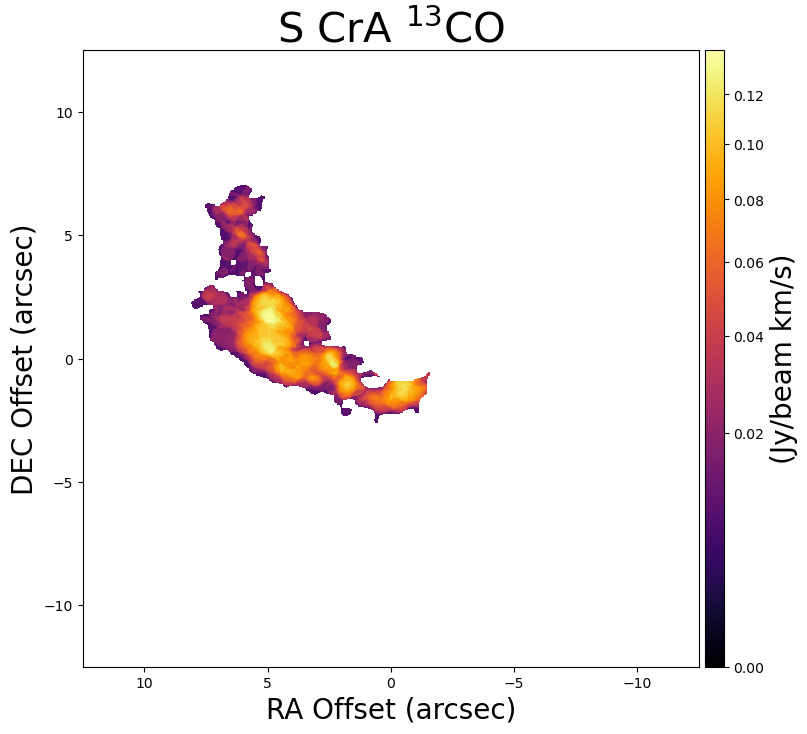

In [33]:
# ----------- input -----------
# parameters for plot
# moment I map in color
cmap       = 'inferno'  # color

# 獲取新中心點的世界坐標 (R.A._ref, Dec._ref)
ref_world = w.pixel_to_world(new_center[1], new_center[0])
ra_ref_deg = ref_world.ra.deg
dec_ref_deg = ref_world.dec.deg

# 獲取影像的像素維度
nx = header['NAXIS1']
ny = header['NAXIS2']

# 定義四個角落的像素坐標 (X 軸)
# 使用 np.array 進行向量化
x_pixels = np.array([0, nx - 1, 0, nx - 1])
y_pixels = np.array([0, 0, ny - 1, ny - 1])

# 透過 WCS 一次性轉換所有角落的坐標 (這是最關鍵的一步)
corner_worlds = w.pixel_to_world(x_pixels, y_pixels)

# 提取 R.A. 和 Dec. 的度數陣列
corner_ra_deg = corner_worlds.ra.deg
corner_dec_deg = corner_worlds.dec.deg

# 計算 R.A. 偏移 (度 -> 角秒)
ra_offset_arcsec = (corner_ra_deg - ra_ref_deg) * 3600. * np.cos(np.deg2rad(dec_deg))

# 計算 Dec 偏移 (度 -> 角秒)
dec_offset_arcsec = (corner_dec_deg - dec_ref_deg) * 3600.

# extent 格式為 (xmin, xmax, ymin, ymax)
# x 軸 (R.A.)
xmin_arcsec = np.min(ra_offset_arcsec)
xmax_arcsec = np.max(ra_offset_arcsec)

# y 軸 (Dec)
ymin_arcsec = np.min(dec_offset_arcsec)
ymax_arcsec = np.max(dec_offset_arcsec)

# 最終的 extent
extent = (xmax_arcsec, xmin_arcsec, ymin_arcsec, ymax_arcsec)

# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0, vmax=np.nanmax(shifted_str_mom0))  # Adjust gamma for better visibility

imcolor = ax.imshow(shifted_str_mom0, origin='lower',
    cmap=cmap, extent=extent, norm=norm)
plt.gca().set_aspect('equal') 

# color bar
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

# range
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)

# save/show
folder_path = "image"
outname  = 'S CrA'  # outputname
# plt.savefig(os.path.join(folder_path, outname+'.png'), dpi=300, bbox_inches='tight')

plt.show()


In [34]:
# -----------------------------------------------------------------------
# 1. 建立 3D 座標網格
# -----------------------------------------------------------------------
# 這裡 v, z, x 是像素編號，與 cube_shape (v, z, x) 順序一致
v, z, x = np.indices(cube_shape)
# 相對於參考像素的座標
x_rel = x - im_center[1]
z_rel = z - im_center[0]

# 計算每個體素的球座標 (r, theta)
# r, theta 會是 3D 陣列，與 data_cube 相同維度
r, theta = pss.spherical_coords(x_rel, z_rel)

N_elements = 10
pars = np.linspace(40, 160, N_elements + 1)  # 徑向距離區間

x_means = np.zeros(N_elements)
z_means = np.zeros(N_elements)
v_means = np.zeros(N_elements)
xzstd = np.zeros(N_elements)

x_array_list = []
z_array_list = []
v_array_list = []
weights_list = []

# -----------------------------------------------------------------------
# 2. 找到每個徑向區間的 xz 平均座標
# -----------------------------------------------------------------------
for i in range(N_elements):
    r_streaml = (pars[i] + pars[i+1]) / 2
    theta0 = find_streaml(r_streaml)

    # 計算 3D 權重陣列
    weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r
    # 處理 r=0 的情況
    weight_theta[r==0] = 0
    
    # ⚠️ 
    # weight_theta[weight_theta < 0.99] = 0

    # 找出指定徑向範圍和有效數據的體素
    dinds = (r > pars[i]) & (r <= pars[i+1]) & np.isfinite(shifted_cube_data) & (shifted_cube_data > 0)    

    # 這裡的邏輯已經是正確的，但為了除錯，我們可以加入打印語句
    if np.sum(dinds) > 0:
        x_means[i] = np.average(x_rel[dinds], weights=shifted_cube_data[dinds] * weight_theta[dinds])
        z_means[i] = np.average(z_rel[dinds], weights=shifted_cube_data[dinds] * weight_theta[dinds])
        xzstd[i] = np.sqrt(np.average((x_rel[dinds] - x_means[i]) ** 2 + (z_rel[dinds] - z_means[i]) ** 2, weights=shifted_cube_data[dinds] * weight_theta[dinds]))
    else:
        x_means[i] = np.nan
        z_means[i] = np.nan
        xzstd[i] = np.nan

# -----------------------------------------------------------------------
# 3. 創建內插函數，用於計算高斯權重
# -----------------------------------------------------------------------
# 篩選掉 NaN 值，確保內插函數正確
valid_means_mask = np.isfinite(x_means)
if np.sum(valid_means_mask) < 2:
    print("數據太稀疏，無法建立內插函數，請檢查數據或參數")
    # 返回一個空的陣列或直接退出
    streamercom_v_pix = np.array([])
    streamercom_z_pix = np.array([])
    streamercom_x_pix = np.array([])
else:
    r_means, theta_means = pss.spherical_coords(x_means[valid_means_mask], z_means[valid_means_mask])
    theta_r = interp1d(r_means, theta_means, fill_value=(theta_means[0], theta_means[-1]), bounds_error=False)
    std_r = interp1d(r_means, xzstd[valid_means_mask], fill_value=(xzstd[0], xzstd[-1]), bounds_error=False)

    # -----------------------------------------------------------------------
    # 4. 計算 v, z, x 的加權平均
    # -----------------------------------------------------------------------
    for i in range(N_elements):
        r_ref = (pars[i] + pars[i+1]) / 2
        
        # 如果徑向區間無效，直接跳過
        if not np.isfinite(x_means[i]):
            x_means[i] = np.nan
            z_means[i] = np.nan
            v_means[i] = np.nan
            continue
            
        theta_ref = theta_r(r_ref)
        std_ref = std_r(r_ref) / r_ref
        
        # 計算 3D 高斯權重
        delta_theta = np.pi - np.abs(np.pi - np.abs(theta - theta_ref))
        weights = shifted_cube_data * pss.gaussian(delta_theta, 0, std_ref)
        
        dinds = (r > pars[i]) & (r <= pars[i+1]) & np.isfinite(shifted_cube_data) & (shifted_cube_data > 0)

        # 存儲每次迴圈的值
        x_array_list.append(x_rel[dinds])
        z_array_list.append(z_rel[dinds])
        v_array_list.append(v[dinds])
        weights_list.append(weights[dinds])
        
        # 計算加權平均
        x_means[i] = np.average(x_rel[dinds], weights=weights[dinds])  
        z_means[i] = np.average(z_rel[dinds], weights=weights[dinds])
        v_means[i] = np.average(v[dinds], weights=weights[dinds])
        print(f"區間 {i}: x_means={x_means[i]}, z_means={z_means[i]}, v_means={v_means[i]}")


x_rotated = x_means * np.cos(pa_rad) + z_means * np.sin(pa_rad)
z_rotated = -x_means * np.sin(pa_rad) + z_means * np.cos(pa_rad)

# 轉換為物理單位
streamercom_x_AU = x_rotated * dx_au
streamercom_z_AU = z_rotated * dx_au
streamercom_v_km = v_lastch_vel + (v_means - v_lastch_num) * dv
streamercom_v_LS_km = streamercom_v_km - Local_Standard_Velocity
print(f"最終的像素座標 (x, z):")
print(f"X: {x_means}")
print(f"Z: {z_means}")
print(f"像素中心: {im_center}")

print(f"\n旋轉後的相對像素座標 (x, z):")
print(f"X: {x_rotated}")
print(f"Z: {z_rotated}")

print(f"從 3D 立方體中提取了 {np.sum(np.isfinite(x_means))} 個有效點。")

/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_79320/129863047.py:35: RuntimeWarning: invalid value encountered in divide
  weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r


區間 0: x_means=-5.322027437971966, z_means=-44.30129795587564, v_means=41.12077487454129
區間 1: x_means=-43.774173186514275, z_means=-34.45683980834362, v_means=37.62378312409624
區間 2: x_means=-64.1583817533343, z_means=-22.653754400251785, v_means=35.823757309682875
區間 3: x_means=-79.24532460337872, z_means=-17.40386974812016, v_means=35.10271510079158
區間 4: x_means=-87.1934405171412, z_means=-32.55954125433071, v_means=34.52920591712684
區間 5: x_means=-104.94236107879227, z_means=3.022090051444322, v_means=36.47229713301955
區間 6: x_means=-116.19482474977653, z_means=8.961587013350666, v_means=36.62174861615116
區間 7: x_means=-126.921942218518, z_means=14.341123293379857, v_means=36.874205890513046
區間 8: x_means=-137.40191087257404, z_means=25.285434059789623, v_means=37.5196027315202
區間 9: x_means=-141.3920921652091, z_means=55.184799410877034, v_means=39.39225295189483
最終的像素座標 (x, z):
X: [  -5.32202744  -43.77417319  -64.15838175  -79.2453246   -87.19344052
 -104.94236108 -116.19482475 

In [ ]:
pars

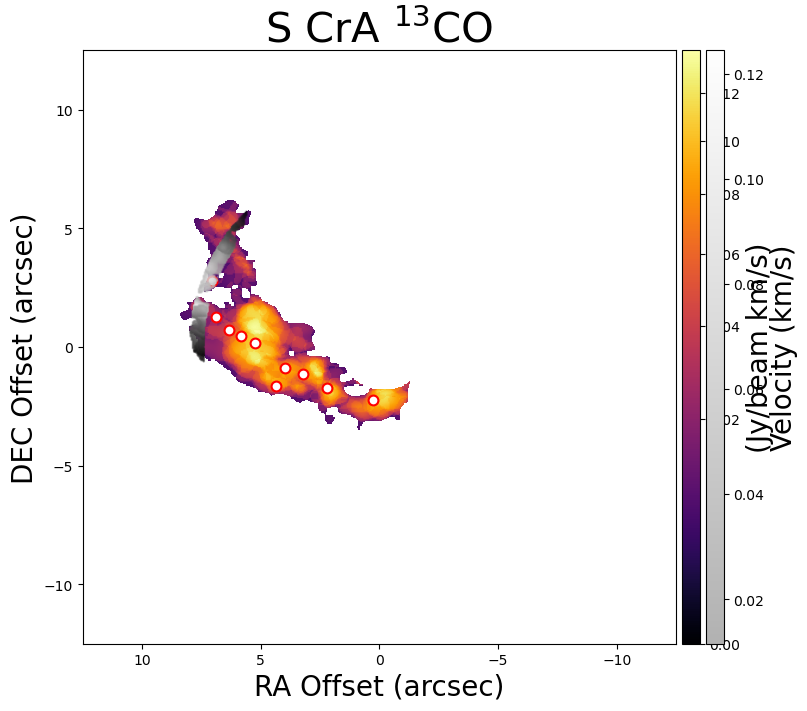

In [35]:
# ----------- input -----------
# parameters for plot
# moment I map in color
cmap       = 'inferno'  # color

# 獲取新中心點的世界坐標 (R.A._ref, Dec._ref)
ref_world = w.pixel_to_world(new_center[1], new_center[0])
ra_ref_deg = ref_world.ra.deg
dec_ref_deg = ref_world.dec.deg

streamercom_world = w.pixel_to_world(x_means + new_center[1], z_means + new_center[0])

streamercom_ra_arcsec = (streamercom_world.ra.deg - ra_ref_deg) * 3600. * np.cos(np.deg2rad(dec_ref_deg))
streamercom_dec_arcsec = (streamercom_world.dec.deg - dec_ref_deg) * 3600.

# --- 3. 計算 shifted_str_mom0 的正確 extent ---
# extent 必須描述 shifted_str_mom0 這個陣列的物理邊界
# 在這個陣列中，im_center 像素點對應的是天空中的 new_center 位置（即圖上的 0,0）
rows, cols = shifted_str_mom0.shape
dx_arcsec = abs(header['CDELT1']) * 3600.
dz_arcsec = abs(header['CDELT2']) * 3600.

# 計算陣列四個角落的像素，相對於 im_center 的偏移量，再轉換為角秒
# RA 偏移 (X 軸)
ra_min_offset = (0 - im_center[1]) * dx_arcsec
ra_max_offset = (cols - im_center[1]) * dx_arcsec
# DEC 偏移 (Z 軸/Y 軸)
dec_min_offset = (0 - im_center[0]) * dz_arcsec
dec_max_offset = (rows - im_center[0]) * dz_arcsec

# extent 格式為 (left, right, bottom, top)
# RA 軸是反的，所以 left 對應 max_offset, right 對應 min_offset
extent = [ra_max_offset, ra_min_offset, dec_min_offset, dec_max_offset]
# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0, vmax=np.nanmax(shifted_str_mom0))  # Adjust gamma for better visibility

imcolor = ax.imshow(shifted_str_mom0, origin='lower',
    cmap=cmap, extent=extent, norm=norm)
plt.gca().set_aspect('equal') 

ax.scatter(0, 0, c='w', s=100, marker='+')
ax.scatter(streamercom_ra_arcsec, streamercom_dec_arcsec,
           c='white', s=50, marker='o', edgecolors='red', linewidths=1.5,
           label='Streamer Centroids')# range

weight_world = w.pixel_to_world(x_array_list[9] + new_center[1], z_array_list[9] + new_center[0])
weight_ra_arcsec = (weight_world.ra.deg - ra_ref_deg) * 3600. * np.cos(np.deg2rad(dec_ref_deg))
weight_dec_arcsec = (weight_world.dec.deg - dec_ref_deg) * 3600.
sc_weights = ax.scatter(weight_ra_arcsec, weight_dec_arcsec, c=weights_list[9], s=1, alpha=0.3, cmap='grey')

# color bar
divider = make_axes_locatable(ax)

# --- MODIFICATION 2: 添加兩個 colorbar ---
# Colorbar 1 (針對背景的 moment 0 圖)
cax1 = divider.append_axes('right', size='3%', pad='1%')
cbar1 = fig.colorbar(imcolor, cax=cax1)
cbar1.set_label('(Jy/beam km/s)',fontsize=20)

# Colorbar 2 (針對您的 scatter 點)
# 我們再次呼叫 append_axes，它會自動將 cax2 附加到 cax1 的右側
cax2 = divider.append_axes('right', size='3%', pad='1%') 
cbar2 = fig.colorbar(sc_weights, cax=cax2) # 傳入 scatter 物件 sc_weights
cbar2.set_label('Velocity (km/s)', fontsize=20) # 為新的 colorbar 命名

# range
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)

# save/show
folder_path = "image"
outname  = 'S CrA'  # outputname
# plt.savefig(os.path.join(folder_path, outname+'.png'), dpi=300, bbox_inches='tight')

plt.show()


NameError: name 'shifted_str_mom1' is not defined

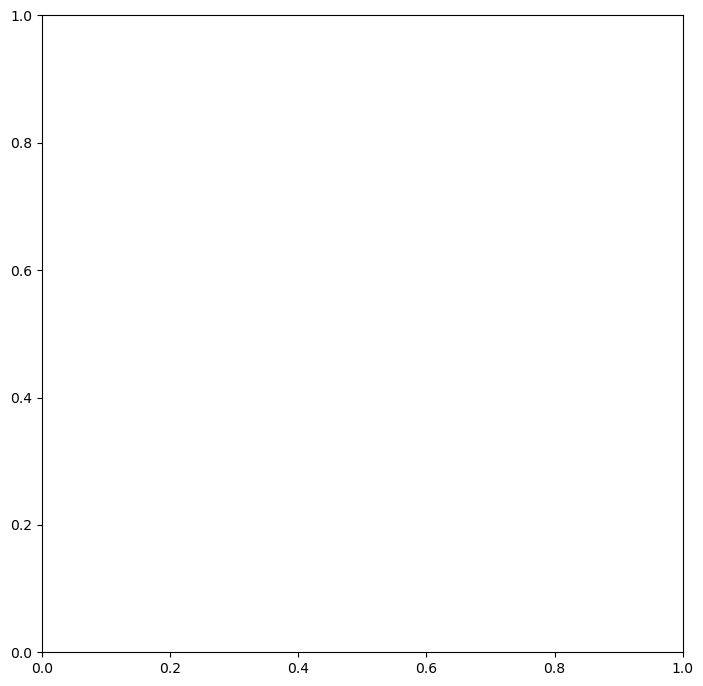

In [2]:
# 繪圖
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
cmap = 'coolwarm'
vmin, vmax = Local_Standard_Velocity - 1, Local_Standard_Velocity + 1   # color range
imcolor = ax.imshow(shifted_str_mom1, origin='lower', cmap=cmap, extent=extent, vmin=vmin, vmax=vmax)
# color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(km/s)',fontsize=20)
ax.scatter(0, 0, c='w', s=100, marker='+')
ax.scatter(streamercom_ra_arcsec, streamercom_dec_arcsec,
           c=streamercom_v_km, cmap=cmap, vmin=vmin, vmax=vmax,
           s=50, marker='o', edgecolors='black', linewidths=1,
           label='Streamer Centroids')# range


ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()

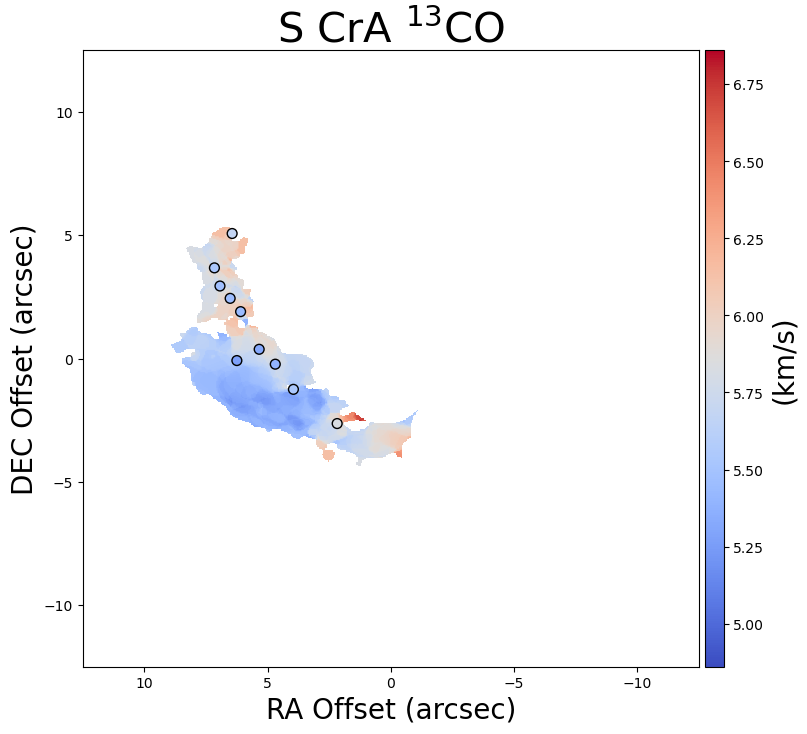

In [37]:
# 從像素座標轉為 WCS 物件
streamercom_rot_world = w.pixel_to_world(x_rotated + new_center[1], z_rotated + new_center[0])

# 計算相對中心的 RA 和 DEC 偏移
streamercom_rot_ra_arcsec = (streamercom_rot_world.ra.deg - header['CRVAL1']) * 3600.
streamercom_rot_dec_arcsec = (streamercom_rot_world.dec.deg - header['CRVAL2']) * 3600.
# 繪圖
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
cmap = 'coolwarm'
vmin, vmax = Local_Standard_Velocity - 1, Local_Standard_Velocity + 1   # color range
imcolor = ax.imshow(str_moment1, origin='lower', cmap=cmap, extent=extent, vmin=vmin, vmax=vmax)
# color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(km/s)',fontsize=20)
ax.scatter(0, 0, c='w', s=100, marker='+')
ax.scatter(streamercom_rot_ra_arcsec, streamercom_rot_dec_arcsec,
           c=streamercom_v_km, cmap=cmap, vmin=vmin, vmax=vmax,
           s=50, marker='o', edgecolors='black', linewidths=1,
           label='Streamer Centroids')# range
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()

In [54]:
P_half_Myr = np.pi / Omega_ref / 1e6 / spc.year

range_start_Myr = 130 * P_half_Myr  # 約 125.6 * t_ff
range_end_Myr   = 300 * P_half_Myr  # 約 157.0 * t_ff
n_theta, n_phi, n_Inclination, n_T_Myr, n_Omega = 10, 10, 10, 10, 10
theta = np.linspace(0, np.pi / 2, n_theta+2)[1:-1]  # `Theta` 的範圍 [0, π]
phi = np.linspace(0, 2*np.pi, n_phi, endpoint=False)  # `Phi` 的範圍 [0, 2π]
# T_Myr = np.linspace(40, 50, n_T_Myr) * np.pi / Omega_ref / 1e6 / spc.year# `Time` 的範圍 [1e-2, 1e-1]
T_Myr = np.logspace(np.log10(range_start_Myr), np.log10(range_end_Myr), n_T_Myr)
Inclination = np.linspace(-np.pi / 2, np.pi / 2, n_Inclination+2)[1:-1]  # `Inclination` 的範圍 [-π/2, π/2]
omega = np.linspace(0, 1, n_Omega+1)[1:]
error = np.zeros((n_theta, n_phi, n_T_Myr, n_Inclination, n_Omega))

for i_theta in range(n_theta):
    for i_phi in range(n_phi):
        for i_T_Myr in range(n_T_Myr):
            for i_Inclination in range(n_Inclination):
                for i_Omega in range(n_Omega):
                    error[i_theta, i_phi, i_T_Myr, i_Inclination, i_Omega] = pss.error_function([theta[i_theta], phi[i_phi]], streamercom_x_AU, streamercom_z_AU, streamercom_v_LS_km, 
                                                                                                v_weight_for_cube, T_Myr[i_T_Myr], omega[i_Omega], Inclination[i_Inclination], M_star, scale='log', log_power=1.5)

In [61]:
min_theta, min_phi, min_Inclination, min_T_Myr, min_Omega = np.unravel_index(np.argmin(error), error.shape)
M_0 = M_star * M_SUN_KG * spc.G / (200 ** 3 * T_Myr[min_T_Myr] * spc.year * 1e6) 
M_dot = M_star * M_SUN_KG / (T_Myr[min_T_Myr] * 1e6) / (M_star * M_SUN_KG)#

print(np.shape(error))
print(np.unravel_index(np.argmin(error), error.shape))
print(min_theta, min_phi, min_T_Myr, min_Inclination)
print('Theta = ' + str(np.rad2deg(theta[min_theta])) + ' deg')
print('Phi = ' + str(np.rad2deg(phi[min_phi])) + ' deg')
print('Time = ' + str(T_Myr[min_T_Myr]) + ' Myr')
print('Inclination = ' + str(np.rad2deg(Inclination[min_Inclination])) + ' deg')
print('Omega = '+ str(omega[min_Omega]))
print(M_0)
print(T_Myr[min_T_Myr] * spc.year * 1e6 * 200 / spc.astronomical_unit)
print('Mass accretion rate = ' + str(M_dot) + ' M_star/yr')

(10, 10, 10, 10, 10)
(7, 0, 7, 0, 2)
7 0 0 7
Theta = 65.45454545454545 deg
Phi = 0.0 deg
Time = 0.17100712965881842 Myr
Inclination = 40.909090909090914 deg
Omega = 0.30000000000000004
7.936584809264836
7209.836364229078
Mass accretion rate = 5.847709402497608e-06 M_star/yr


In [58]:
T_Myr

array([0.17100713, 0.1876581 , 0.20593038, 0.22598183, 0.24798569,
       0.27213207, 0.29862958, 0.32770715, 0.35961601, 0.39463184])

In [ ]:
Theta_init = theta[min_theta]
Phi_init = phi[min_phi]
Inclination_init = Inclination[min_Inclination]
T_init = T_Myr[min_T_Myr]
Omega_init = omega[min_Omega]

In [ ]:
# -----------------------------------------------------------------------
# 動態設定 MCMC 的參數範圍 (已加入邊界檢查)
# -----------------------------------------------------------------------
parameter_prior_ranges = {
    # Theta: 確保索引不會小於 0 或大於陣列長度
    'Theta zero': (theta[max(0, min_theta - 1)], theta[min(len(theta) - 1, min_theta + 1)]),
    
    # Phi: 確保索引不會小於 0 或大於陣列長度
    'Phi zero': (phi[max(0, min_phi - 1)], phi[min(len(phi) - 1, min_phi + 1)]),
    
    # Inclination: 確保索引不會小於 0 或大於陣列長度
    'Inclination': (Inclination[max(0, min_Inclination - 1)], Inclination[min(len(Inclination) - 1, min_Inclination + 1)]),    
    
    # Time: 確保索引不會小於 0 或大於陣列長度
    'Time': (T_Myr[max(0, min_T_Myr - 1)], T_Myr[min(len(T_Myr) - 1, min_T_Myr + 1)]),
    
    # Omega: 確保索引不會小於 0 或大於陣列長度
    'Omega': (omega[max(0, min_Omega - 1)], omega[min(len(omega) - 1, min_Omega + 1)]),
}

# 打印新的範圍以供檢查
print("MCMC 參數的新範圍:")
for param, (min_val, max_val) in parameter_prior_ranges.items():
    if param in ["Theta zero", "Phi zero", "Inclination"]:
        print(f"{param:<12s}: ({np.rad2deg(min_val):.2f}, {np.rad2deg(max_val):.2f}) deg")
    elif param == 'Time':
        print(f"{param:<12s}: ({min_val:.4f}, {max_val:.4f}) Myr")
    else:
        print(f"{param:<12s}: ({min_val:.2f}, {max_val:.2f})")

In [ ]:
# # -----------------------------------------------------------------------
# # 動態設定 MCMC 的參數範圍 (已加入邊界檢查)
# # -----------------------------------------------------------------------
# parameter_prior_ranges = {
#     # Theta: 確保索引不會小於 0 或大於陣列長度
#     'Theta0': (theta[0], theta[9]),
    
#     # Phi: 確保索引不會小於 0 或大於陣列長度
#     'Phi0': (phi[0], phi[9]),
    
#     # Inclination: 確保索引不會小於 0 或大於陣列長度
#     'Incl': (Inclination[0], Inclination[9]),

#     # Time: 確保索引不會小於 0 或大於陣列長度
#     'T': (T_Myr[0], T_Myr[9]),

#     # Omega: 確保索引不會小於 0 或大於陣列長度
#     'Omega': (omega[0], omega[9]),
# }

# # 打印新的範圍以供檢查
# print("MCMC 參數的新範圍:")
# for param, (min_val, max_val) in parameter_prior_ranges.items():
#     if param in ['Theta0', 'Phi0', 'Incl']:
#         print(f"{param:<12s}: ({np.rad2deg(min_val):.2f}, {np.rad2deg(max_val):.2f}) deg")
#     elif param == 'T':
#         print(f"{param:<12s}: ({min_val:.4f}, {max_val:.4f}) Myr")
#     else:
#         print(f"{param:<12s}: ({min_val:.2f}, {max_val:.2f})")

In [ ]:
# 1. 建立一個包含所有初始參數的陣列
initial_guess = np.array([Theta_init, Phi_init, Inclination_init, T_init, Omega_init])

ndim = 5 # 參數數量
nwalkers = 20

# 2. 確保每個參數的擾動都以 initial_guess 為中心
initial_pos = np.zeros((nwalkers, ndim))

labels = ["Theta zero", "Phi zero", "Inclination", "Time", "Omega"]


for i in range(ndim):
    key = labels[i]
        
    # 直接獲取 MCMC 所使用的精確先驗範圍 [min, max]
    min_range = parameter_prior_ranges[key][0]
    max_range = parameter_prior_ranges[key][1]
    
    # 最終的初始位置：在精確的先驗範圍內均勻分佈
    initial_pos[:, i] = np.random.uniform(min_range, max_range, nwalkers)

In [ ]:
# ----------------------------------------------------------------------
# 檢查初始位置分佈
# ----------------------------------------------------------------------
print("---------------- MCMC 初始採樣點分佈檢查 (nwalkers={}) ----------------".format(nwalkers))

for i, label in enumerate(labels):
    data = initial_pos[:, i] # 這是 nwalkers 的實際採樣點
    
    # --- 核心修改 ---
    # 不再從 data 中計算 np.min/np.max，
    # 而是直接從您定義的先驗範圍中提取
    min_val_theory = parameter_prior_ranges[label][0]
    max_val_theory = parameter_prior_ranges[label][1]
    # --- 修改結束 ---

    # 針對角度參數，轉換為度數以供檢查
    if label in ["Theta zero", "Phi zero", "Inclination"]:
        # 轉換理論邊界
        min_val_print = np.rad2deg(min_val_theory)
        max_val_print = np.rad2deg(max_val_theory)
        # 仍然計算實際採樣點的中位數
        median_val = np.median(np.rad2deg(data))
        unit = "deg"
    else:
        # 非角度參數
        min_val_print = min_val_theory
        max_val_print = max_val_theory
        # 仍然計算實際採樣點的中位數
        median_val = np.median(data)
        unit = ""
    
    # 打印理論範圍 (Min/Max) 和實際中位數 (Median)
    print(f"[{label:<11s}]: Median (Sample): {median_val:<.6f}, Defined Min: {min_val_print:<.6f}, Defined Max: {max_val_print:<.6f} {unit}")

print("-----------------------------------------------------------------------")

In [ ]:
x_model, y_model, z_model, u_model, v_model, w_model = pss.PSS_model(Theta_init, Phi_init, Inclination_init, T_init, Omega_init, M_star, radius_in_au, radius_out_au, 100)

# 將物理座標轉換為像素座標
x_pix_rotated = x_model / AU_per_pixel
z_pix_rotated = z_model / AU_per_pixel
x_pix = x_pix_rotated * np.cos(pa_rad) - z_pix_rotated * np.sin(pa_rad) + im_center[1]
z_pix = x_pix_rotated * np.sin(pa_rad) + z_pix_rotated * np.cos(pa_rad) + im_center[0]
v_pix = v_lastch_num + ((v_model + Local_Standard_Velocity) - v_lastch_vel) / dv

# 根據所有初始模型線的座標，計算一個包含所有點的邊界框
buffer = 120 # 可以設定一個合適的緩衝值
v_buffer = 20
search_bound = pss.get_bounding_box(x_pix, z_pix, v_pix, buffer, v_buffer,cube_shape)

print(f"MCMC 採樣器的初始邊界框為：{search_bound}")

In [ ]:
# --- 1. 從 search_bound 中提取 8 個頂點的座標 ---
(v_min, v_max), (z_min, z_max), (x_min, x_max) = search_bound

# 定義 8 個頂點的 (x, z, v) 座標
# (請注意，Plotly 的 Y 軸我們用來對應 z_pix, Z 軸對應 v_pix)
vertices_x = [x_min, x_max, x_max, x_min, x_min, x_max, x_max, x_min]
vertices_z = [z_min, z_min, z_max, z_max, z_min, z_min, z_max, z_max]
vertices_v = [v_min, v_min, v_min, v_min, v_max, v_max, v_max, v_max]

# 定義 12 條邊 (用頂點的索引 0-7)
# (0,1), (1,2), (2,3), (3,0) -> 底部
# (4,5), (5,6), (6,7), (7,4) -> 頂部
# (0,4), (1,5), (2,6), (3,7) -> 垂直邊
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),
    (4, 5), (5, 6), (6, 7), (7, 4),
    (0, 4), (1, 5), (2, 6), (3, 7)
]

# --- 2. 建立用於繪製 12 條線的座標陣列 ---
# 我們在每條線的結尾加上 None，這樣 Plotly 就不會把它們連在一起
lines_x = []
lines_z = []
lines_v = []
for (start_idx, end_idx) in edges:
    lines_x.extend([vertices_x[start_idx], vertices_x[end_idx], None])
    lines_z.extend([vertices_z[start_idx], vertices_z[end_idx], None])
    lines_v.extend([vertices_v[start_idx], vertices_v[end_idx], None])

# --- 3. 建立 Plotly 圖表 ---
fig = go.Figure()

# 追蹤 1: 您計算出的 PSS_model 點
fig.add_trace(go.Scatter3d(
    x=x_pix,
    y=z_pix,  # 將 z_pix 映射到 Y 軸
    z=v_pix,  # 將 v_pix 映射到 Z 軸
    mode='markers',
    marker=dict(size=2, color='blue'),
    name='Model Points'
))

# 追蹤 2: search_bound 的線框
fig.add_trace(go.Scatter3d(
    x=lines_x,
    y=lines_z,
    z=lines_v,
    mode='lines',
    line=dict(color='gray', width=2),
    name='Search Bound'
))

x_axis_range = [30, 510]
y_axis_range = [195, 675]
z_axis_range = [15, 70]
# --- 4. 設定圖表佈局 ---
fig.update_layout(
    title="MCMC 採樣邊界框 (Search Bound)",
    scene=dict(
        xaxis_title="X 像素",
        yaxis_title="Z 像素",
        zaxis_title="V 通道 (Channel)",
        xaxis = dict(nticks=4, range=x_axis_range,),
        yaxis = dict(nticks=4, range=y_axis_range,),
        zaxis = dict(nticks=4, range=z_axis_range,),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=1)
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [ ]:
# MCMC 採樣器初始化
sampler_short = emcee.EnsembleSampler(
    nwalkers, 
    ndim, 
    pss.log_posterior, 
    args=(new_cube_data, search_bound, parameter_prior_ranges, pa_rad, AU_per_pixel, im_center, dv, v_lastch_vel, v_lastch_num, Local_Standard_Velocity, v_weight_for_cube, max_dist_value, M_star, radius_in_au, radius_out_au)
)
Nsteps = 150  # 運行 10000 步
Burnin = 10  # 丟棄前 1000 步

# 運行採樣
print("開始 MCMC 採樣...")
sampler_short.run_mcmc(initial_pos, Nsteps, progress=True)
print("MCMC 採樣完成。")

# # 獲取樣本 (確保 Nsteps > Burnin)
# samples_short = sampler_short.get_chain(discard=Burnin, flat=True)

# # 檢查樣本數量
# print(f"最終樣本數量: {samples_short.shape[0]}")

In [ ]:
# 獲取樣本 (確保 Nsteps > Burnin)
samples_short = sampler_short.get_chain(discard=Burnin, flat=True)

# 檢查樣本數量
print(f"最終樣本數量: {samples_short.shape[0]}")

In [ ]:
ndim = 5

# --- 1. 根本解決方案：預先轉換角度數據 ---
# 這是修正標題的關鍵！
print("正在將 MCMC 採樣結果中的弧度轉換為角度...")
samples_for_plot = np.copy(samples_short)
angle_indices = [0, 1, 2] # 角度參數的索引 ("Theta0", "Phi0", "Inclination")
time_index = 3

for idx in angle_indices:
    samples_for_plot[:, idx] = np.rad2deg(samples_for_plot[:, idx])

# --- 2. 建立新的標籤 (為角度加上單位) ---
new_labels = []
for i, label in enumerate(labels):
    if i in angle_indices:
        new_labels.append(label + " (°)") # 例如 "Theta0 (°)"
    elif i == time_index:
        new_labels.append(label + " (Myr)") # "T (Myr)"
    else:
        new_labels.append(label) # "Omega" 保持不變

# --- 3. 繪製 Corner Plot ---
# 因為我們傳入的是 "samples_for_plot" (角度數據)，
# 所以 show_titles=True 會自動計算出「角度」的標題，
# 並且座標軸也會自動使用「角度」的刻度。
fig = corner.corner(
    samples_for_plot, 
    labels=new_labels, 
    show_titles=True,
    title_fmt='.2f' # 讓所有標題（包括 T）都顯示為小數點後 2 位
)

# --- 4. 後期處理：為 T 和 Omega 客製化軸標籤 (如您所願) ---
print("正在為 T 和 Omega 參數的座標軸添加客製化格式...")
axes = np.array(fig.get_axes()).reshape(ndim, ndim)

# T 的索引
time_idx = 3 
if ndim > time_idx:
    ax_x_time = axes[ndim-1, time_idx] # T 的 X 軸
    ax_y_time = axes[time_idx, 0]     # T 的 Y 軸
    
    # 應用您想要的 "Myr" 格式
    ax_x_time.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.2f} Myr'))
    ax_y_time.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.2f} Myr'))

# Omega 的索引
omega_idx = 4 
if ndim > omega_idx:
    ax_x_omega = axes[ndim-1, omega_idx] # Omega 的 X 軸
    ax_y_omega = axes[omega_idx, 0]     # Omega 的 Y 軸
    
    # 應用您想要的 "%.2f" 格式
    ax_x_omega.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax_y_omega.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# 3. 最後顯示您修改過的「一張圖」
print("繪圖完成。")
plt.show()

In [ ]:
# 1. 確保你已經運行了 report_and_get_best_params 函式並得到了最佳參數
# 假設 samples 已經是 MCMC 的結果
# 獲取弧度形式的最佳參數
Theta_short_best, Phi_short_best, Inclination_short_best, T_short_best, Omega_short_best = pss.report_and_get_best_params(samples_short, 99.7) 

# 2. 將所有 log_likelihood 所需的常數打包成一個 tuple，方便傳入
# 確保這些變數在你的環境中是可用的
model_short_args = (new_cube_data, search_bound, AU_per_pixel, im_center, dv, v_lastch_num, v_lastch_vel)

In [ ]:
# --- 重建最佳模型與誤差立方體 ---

# 1. 重新生成模型線的像素座標
x_model, y_model, z_model, u_model, v_model, w_model = pss.PSS_model(
    Theta_short_best, Phi_short_best, Inclination_short_best, T_short_best, Omega_short_best, 
    M_star, radius_in_au, radius_out_au, 80, scale='log', log_power=1.5
)
# x_model, y_model, z_model, u_model, v_model, w_model = pss.PSS_model(
#     Theta_init, Phi_init, Inclination_init, T_init, Omega_init, 
#     M_star, radius_in_au, radius_out_au, 100
# )
# 假設 log_likelihood 的參數都在 model_args 裡
data_cube, search_bound, AU_per_pixel, im_center, dv, v_lastch_num, v_lastch_vel = model_short_args

# 將物理座標轉換為整數像素座標
cube_shape = data_cube.shape

x_best_pix_rotated_short = x_model / AU_per_pixel
z_best_pix_rotated_short = z_model / AU_per_pixel
x_best_pix_short = x_best_pix_rotated_short * np.cos(pa_rad) - z_best_pix_rotated_short * np.sin(pa_rad) + im_center[1]
z_best_pix_short = x_best_pix_rotated_short * np.sin(pa_rad) + z_best_pix_rotated_short * np.cos(pa_rad) + im_center[0]
v_best_pix_short = v_lastch_num + ((v_model - v_lastch_vel + Local_Standard_Velocity) / dv)

In [ ]:
# 呼叫距離立方體函式，並確保使用整數座標
model_line_coords = zip(v_best_pix_short, z_best_pix_short, x_best_pix_short)
final_distance_cube = pss.grow_distance_cube_bounded(cube_shape, 
                                                    model_line_coords, 
                                                    max_dist_value, 
                                                    v_weight_for_cube,
                                                    bound=search_bound # **使用裁剪後的邊界**
                                                )

# Exclude points that are outside your search boundary (-1 values)
valid_mask = final_distance_cube > 0
v_dis_coords, z_dis_coords, x_dis_coords = np.where(valid_mask)
distances = final_distance_cube[valid_mask]
data_values = data_cube[valid_mask]
error_cube = np.zeros_like(final_distance_cube, dtype=np.float32)
error_cube[valid_mask] = distances * data_values

# We'll normalize by the maximum value found in the valid data
max_error = np.nanmax(error_cube[valid_mask])

# Handle the case of zero division if max_error is 0
if max_error > 0:
    normalized_error_cube = error_cube / max_error
else:
    normalized_error_cube = error_cube

In [ ]:
x_axis_range = [100, 600]
y_axis_range = [100, 600]
z_axis_range = [0, 70]

mask_error = (normalized_error_cube > 0)
v_error_coords, z_error_coords, x_error_coords = np.where(mask_error)
data_error = normalized_error_cube[mask_error]

v_data, z_data, x_data = np.where(data_cube > 0)

fig = go.Figure(data=go.Scatter3d(
    x=x_dis_coords, y=z_dis_coords, z=v_dis_coords,
    mode='markers',
    name='Distance Points',
    marker=dict(
        size=1,
        color=distances,
        colorscale='inferno_r',
        opacity=0.1,
        cmax=np.max(distances),
        cmin=0,
        colorbar=dict(
            title="Distance",
            len=0.5,
            x=0.95,
        )
    )
) )

fig.add_trace(go.Scatter3d(
    x=x_best_pix_short, y=z_best_pix_short, z=v_best_pix_short,
    mode='markers',
    marker=dict(
        size=3.5, # 點太小 (size=1) 可能看不出邊緣，建議稍為調大
        symbol='circle',
        
        # 這是正確設定邊緣線條的方式 (使用 line 參數)
        line=dict(
            width=0.1, 
            color='grey' # 將邊緣顏色設定為黑色
        ),
        
        # 點的顏色 (填滿色) 仍使用 v_pix
        color=v_best_pix_short,
        colorscale='RdBu_r',
        opacity=0.8,
        cmax=np.max(v_data),
        cmin=np.min(v_data),
        colorbar=dict(
            title="Model",
            len=0.5,
            x=0.8,
        )
    ),
    name="Best Fit Model"
))

fig.update_layout(
    title='Best Fit Model and Distance Cube Distribution',
    scene=dict(
        xaxis_title='X (pixels)',
        yaxis_title='Z (pixels)',
        zaxis_title='V (channels)',
        xaxis = dict(nticks=4, range=x_axis_range,),
        yaxis = dict(nticks=4, range=y_axis_range,),
        zaxis = dict(nticks=4, range=z_axis_range,),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=1)
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)
fig.show()

fig = go.Figure(data=go.Scatter3d(
    x=x_error_coords, y=z_error_coords, z=v_error_coords,
    mode='markers',
    name='Error Points',
    marker=dict(
        size=1,
        color=data_error,
        colorscale='inferno',
        opacity=0.8,
        cmax=1,
        cmin=0,
        colorbar=dict(
            title="Error (normalized)",
            len=0.5,
            x=0.95,
        )
    )
) )

fig.add_trace(go.Scatter3d(
    x=x_best_pix_short, y=z_best_pix_short, z=v_best_pix_short,
    mode='markers',
    marker=dict(
        size=3.5, # 點太小 (size=1) 可能看不出邊緣，建議稍為調大
        symbol='circle',
        
        # 這是正確設定邊緣線條的方式 (使用 line 參數)
        line=dict(
            width=0.1, 
            color='grey' # 將邊緣顏色設定為黑色
        ),
        
        # 點的顏色 (填滿色) 仍使用 v_pix
        color=v_best_pix_short,
        colorscale='RdBu_r',
        opacity=0.8,
        cmax=np.nanmax(v_data),
        cmin=np.nanmin(v_data),
        colorbar=dict(
            title="Model",
            len=0.5,
            x=0.8,
        )
    ),
    name="Best Fit Model"
))

fig.update_layout(
    title='Best Fit Model and Observation error Distribution',
    scene=dict(
        xaxis_title='X (pixels)',
        yaxis_title='Z (pixels)',
        zaxis_title='V (channels)',
        xaxis = dict(nticks=4, range=x_axis_range,),
        yaxis = dict(nticks=4, range=y_axis_range,),
        zaxis = dict(nticks=4, range=z_axis_range,),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=1)
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)
fig.show()


fig = go.Figure(data=go.Scatter3d(
    x=x_data, y=z_data, z=v_data,
    mode='markers',
    marker=dict(
        size=1,
        color=v_data,
        colorscale='RdBu_r',
        opacity=0.8,
        cmax=np.max(v_data),
        cmin=np.min(v_data),
    ),
    name="Original Data"
) )

fig.add_trace(go.Scatter3d(
    x=x_best_pix_short, y=z_best_pix_short, z=v_best_pix_short,
    mode='markers',
    marker=dict(
        size=3.5, # 點太小 (size=1) 可能看不出邊緣，建議稍為調大
        symbol='circle',
        
        # 這是正確設定邊緣線條的方式 (使用 line 參數)
        line=dict(
            width=0.1, 
            color='grey' # 將邊緣顏色設定為黑色
        ),
        
        # 點的顏色 (填滿色) 仍使用 v_pix
        color=v_best_pix_short,
        colorscale='RdBu_r',
        opacity=0.8,
        cmax=np.max(v_data),
        cmin=np.min(v_data),
        colorbar=dict(
            title="Model & Observations",
            len=0.5,
            x=0.8,
        )
    ),
    name="Best Fit Model"
))

fig.update_layout(
    title='Best Fit Model and Observations Distribution',
    scene=dict(
        xaxis_title='X (pixels)',
        yaxis_title='Z (pixels)',
        zaxis_title='V (channels)',
        xaxis = dict(nticks=4, range=x_axis_range,),
        yaxis = dict(nticks=4, range=y_axis_range,),
        zaxis = dict(nticks=4, range=z_axis_range,),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=1)
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)
fig.show()

In [ ]:
# 從像素座標轉為 WCS 物件
streamerfitcom_world = w.pixel_to_world(x_best_pix_short, z_best_pix_short)

# 計算相對中心的 RA 和 DEC 偏移
streamerfitcom_ra_arcsec = (streamerfitcom_world.ra.deg - header['CRVAL1']) * 3600.
streamerfitcom_dec_arcsec = (streamerfitcom_world.dec.deg - header['CRVAL2']) * 3600.

# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0, vmax=np.nanmax(shifted_str_mom0))  # Adjust gamma for better visibility

imcolor = ax.imshow(shifted_str_mom0, origin='lower',
    cmap='inferno', extent=extent, norm=norm)
plt.gca().set_aspect('equal') 

ax.scatter(0, 0, c='w', s=100, marker='+')
# ax.scatter(streamercom_ra_arcsec, streamercom_dec_arcsec,
#            c='white', s=50, marker='o', edgecolors='red', linewidths=1.5,
#            label='Streamer Centroids')# range
points = np.array([streamerfitcom_ra_arcsec, streamerfitcom_dec_arcsec]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
# 黑色邊框線（稍寬一點蓋底）
lc_edge = LineCollection(segments, colors='black', linewidth=10, zorder=1)
ax.add_collection(lc_edge)

# 建立 colormap 的 LineCollection
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
lc = LineCollection(segments, cmap='coolwarm', norm=norm, zorder=2)
lc.set_array(v_model + Local_Standard_Velocity)  # 對應每段顏色
lc.set_linewidth(8)         # 主線寬度
ax.add_collection(lc)       # 加到圖上
ax.add_collection(lc)
ax.add_collection(lc)
# color bar
divider = make_axes_locatable(ax)

# --- MODIFICATION 2: 添加兩個 colorbar ---
# Colorbar 1 (針對背景的 moment 0 圖)
cax1 = divider.append_axes('right', size='3%', pad='1%')
cbar1 = fig.colorbar(imcolor, cax=cax1)
cbar1.set_label('(Jy/beam km/s)',fontsize=20)

# range
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)

# save/show
folder_path = "image"
outname  = 'S CrA'  # outputname
# plt.savefig(os.path.join(folder_path, outname+'.png'), dpi=300, bbox_inches='tight')

plt.show()

In [ ]:

# 繪圖
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
cmap = 'coolwarm'
vmin, vmax = Local_Standard_Velocity - 1, Local_Standard_Velocity + 1   # color range
imcolor = ax.imshow(shifted_str_mom1, origin='lower', cmap=cmap, extent=extent, vmin=vmin, vmax=vmax)
# color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(km/s)',fontsize=20)
ax.scatter(0, 0, c='w', s=100, marker='+')
# ax.scatter(streamercom_ra_arcsec, streamercom_dec_arcsec,
#            c=streamercom_v_km, cmap=cmap, vmin=vmin, vmax=vmax,
#            s=50, marker='o', edgecolors='black', linewidths=1,
#            label='Streamer Centroids')# range
# 黑色邊框線（稍寬一點蓋底）
lc_edge = LineCollection(segments, colors='black', linewidth=10, zorder=1)
ax.add_collection(lc_edge)

# 建立 colormap 的 LineCollection
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
lc = LineCollection(segments, cmap='coolwarm', norm=norm, zorder=2)
lc.set_array(v_model + Local_Standard_Velocity)  # 對應每段顏色
lc.set_linewidth(8)         # 主線寬度
ax.add_collection(lc)       # 加到圖上
ax.add_collection(lc)
ax.add_collection(lc) 
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()